In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for scannable, clean visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
# Load the Excel file (replace 'water_data.xlsx' with your actual file name)
# Assumes columns are named 'time' and 'consumption'
df = pd.read_excel("datasets/QatarClayBricksCo-1222227.xlsx", header=2)

# Ensure the time column is parsed correctly as datetime
df['Hourly'] = pd.to_datetime(df['Hourly'])

# Sort by time to ensure chronological order for rolling calculations
df = df.sort_values('Hourly').reset_index(drop=True)

# Inspect the first few rows
print(df.head())
print(f"Dataset spans from {df['Hourly'].min()} to {df['Hourly'].max()}")

               Hourly  Consumption m3
0 2025-10-22 20:00:00           5.459
1 2025-10-22 21:00:00           5.601
2 2025-10-22 22:00:00           3.651
3 2025-10-22 23:00:00           4.646
4 2025-10-23 00:00:00           4.975
Dataset spans from 2025-10-22 20:00:00 to 2026-03-29 23:00:00


In [7]:
# Extract time features for baseline grouping
df['hour'] = df['Hourly'].dt.hour
df['day_of_week'] = df['Hourly'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Identify the timeline thresholds for your 5-month dataset
max_date = df['Hourly'].max()
four_weeks_ago = max_date - pd.Timedelta(weeks=4)

# Create a column to easily separate your "Recent Month" from "Historical Months"
df['period'] = np.where(df['Hourly'] >= four_weeks_ago, 'Recent', 'Historical')

print(df['period'].value_counts())

period
Historical    2691
Recent         673
Name: count, dtype: int64


In [9]:
df.head()

,Hourly,Consumption m3,hour,day_of_week,is_weekend,period
0,2025-10-22 20:00:00,5.459,20,2,0,Historical
1,2025-10-22 21:00:00,5.601,21,2,0,Historical
2,2025-10-22 22:00:00,3.651,22,2,0,Historical
3,2025-10-22 23:00:00,4.646,23,2,0,Historical
4,2025-10-23 00:00:00,4.975,0,3,0,Historical


In [11]:
# --- Baseline 1: Recent 4-Week Rolling Median ---
# Filter for just the recent 4 weeks to build the profile
recent_data = df[df['period'] == 'Recent']

# Calculate typical usage for each hour, separated by Weekday vs Weekend
recent_profile = recent_data.groupby(['is_weekend', 'hour'])['Consumption m3'].median().reset_index()
recent_profile.rename(columns={'Consumption m3': 'recent_baseline_m3'}, inplace=True)

# Merge this baseline profile back into the main dataframe
df = pd.merge(df, recent_profile, on=['is_weekend', 'hour'], how='left')


# --- Baseline 2: Historical Minimum Night Flow (MNF) ---
# Filter for early data (Months 1-2 roughly) and deep night hours (1 AM to 4 AM)
historical_night_data = df[(df['period'] == 'Historical') & (df['hour'].isin([1, 2, 3, 4]))]

# Find the absolute minimum or a low percentile (e.g., 5th percentile to avoid rare anomalies)
historical_mnf = historical_night_data['Consumption m3'].quantile(0.05)

print(f"Engineered Features Successfully!")
print(f"-> Historical Minimum Night Flow Baseline: {historical_mnf:.4f} m3")


Engineered Features Successfully!
-> Historical Minimum Night Flow Baseline: 0.9024 m3


In [ ]:
# Display a snapshot of the 4-week baseline profile for weekdays (is_weekend = 0)
print("=== Weekday Hourly Baseline Profile (m3) ===")
print(recent_profile[recent_profile['is_weekend'] == 0][['hour', 'recent_baseline_m3']].to_string(index=False))



=== Weekday Hourly Baseline Profile (m3) ===
 hour  recent_baseline_m3
    0              4.2860
    1              3.1995
    2              2.4350
    3              2.0805
    4              7.4255
    5              9.5060
    6              9.1710
    7              8.7450
    8              6.4190
    9              6.9070
   10              7.6610
   11             10.7590
   12             12.4380
   13             10.7400
   14              7.2180
   15             10.7900
   16             10.1980
   17             10.9830
   18              9.6750
   19              8.1650
   20              7.9475
   21              6.6880
   22              4.2485
   23              4.3415

=== Weekend Hourly Baseline Profile (m3) ===
 hour  recent_baseline_m3
    0              4.2995
    1              3.6585
    2              1.9420
    3              2.0155
    4              6.7090
    5             11.6255
    6              8.7040
    7              6.3190
    8              6.5460

In [13]:
# Display a snapshot of the 4-week baseline profile for weekends (is_weekend = 1)
print("\n=== Weekend Hourly Baseline Profile (m3) ===")
print(recent_profile[recent_profile['is_weekend'] == 1][['hour', 'recent_baseline_m3']].to_string(index=False))



=== Weekend Hourly Baseline Profile (m3) ===
 hour  recent_baseline_m3
    0              4.2995
    1              3.6585
    2              1.9420
    3              2.0155
    4              6.7090
    5             11.6255
    6              8.7040
    7              6.3190
    8              6.5460
    9              8.2230
   10              8.3385
   11             10.5755
   12             12.3830
   13             10.9295
   14              6.7690
   15              9.9315
   16             11.4590
   17             10.9280
   18              8.9480
   19              8.5065
   20              9.0295
   21              6.4170
   22              4.3765
   23              4.1320


In [16]:
df.head()

,Hourly,Consumption m3,hour,day_of_week,is_weekend,period,recent_baseline_m3_x,recent_baseline_m3_y,baseline_std_m3
0,2025-10-22 20:00:00,5.459,20,2,0,Historical,7.9475,7.9475,1.631007
1,2025-10-22 21:00:00,5.601,21,2,0,Historical,6.6880,6.6880,1.293177
2,2025-10-22 22:00:00,3.651,22,2,0,Historical,4.2485,4.2485,1.197620
3,2025-10-22 23:00:00,4.646,23,2,0,Historical,4.3415,4.3415,1.186232
4,2025-10-23 00:00:00,4.975,0,3,0,Historical,4.2860,4.2860,1.148724


In [19]:
# --- 1. Re-calculate the 4-Week Rolling Median Profile ---
# Filter for just the recent 4 weeks using the correct 'Consumption m3' column
recent_data = df[df['period'] == 'Recent']

recent_profile = recent_data.groupby(['is_weekend', 'hour'])['Consumption m3'].median().reset_index()
recent_profile.rename(columns={'Consumption m3': 'recent_baseline_m3'}, inplace=True)

# Remove any old version of 'recent_baseline_m3' if it exists to prevent suffixes like _x or _y
if 'recent_baseline_m3' in df.columns:
    df = df.drop(columns=['recent_baseline_m3'])

# Merge the baseline profile back into the main dataframe
df = pd.merge(df, recent_profile, on=['is_weekend', 'hour'], how='left')


# --- 2. Calculate the Standard Deviation Profile ---
recent_std = recent_data.groupby(['is_weekend', 'hour'])['Consumption m3'].std().reset_index()
recent_std.rename(columns={'Consumption m3': 'baseline_std_m3'}, inplace=True)

# Remove any old version of 'baseline_std_m3' if it exists
if 'baseline_std_m3' in df.columns:
    df = df.drop(columns=['baseline_std_m3'])

# Merge the standard deviation column into the main dataframe
df = pd.merge(df, recent_std, on=['is_weekend', 'hour'], how='left')


# --- 3. Calculate Absolute and Z-Score Deviations ---
# Absolute Deviation = Actual - Baseline
df['abs_deviation_m3'] = df['Consumption m3'] - df['recent_baseline_m3']

# Z-Score Deviation (adds epsilon 1e-5 to prevent division by zero)
df['z_score_deviation'] = df['abs_deviation_m3'] / (df['baseline_std_m3'] + 1e-5)

# Fill missing values for the historical baseline period
df[['abs_deviation_m3', 'z_score_deviation']] = df[['abs_deviation_m3', 'z_score_deviation']].fillna(0)

print("Baselines and deviations calculated successfully!")
df.head()


Baselines and deviations calculated successfully!


,Hourly,Consumption m3,hour,day_of_week,is_weekend,period,recent_baseline_m3_x,recent_baseline_m3_y,baseline_std_m3_x,baseline_std_m3_y,recent_baseline_m3,baseline_std_m3,abs_deviation_m3,z_score_deviation
0,2025-10-22 20:00:00,5.459,20,2,0,Historical,7.9475,7.9475,1.631007,1.631007,7.9475,1.631007,-2.4885,-1.525735
1,2025-10-22 21:00:00,5.601,21,2,0,Historical,6.6880,6.6880,1.293177,1.293177,6.6880,1.293177,-1.0870,-0.840559
2,2025-10-22 22:00:00,3.651,22,2,0,Historical,4.2485,4.2485,1.197620,1.197620,4.2485,1.197620,-0.5975,-0.498902
3,2025-10-22 23:00:00,4.646,23,2,0,Historical,4.3415,4.3415,1.186232,1.186232,4.3415,1.186232,0.3045,0.256693
4,2025-10-23 00:00:00,4.975,0,3,0,Historical,4.2860,4.2860,1.148724,1.148724,4.2860,1.148724,0.6890,0.599791


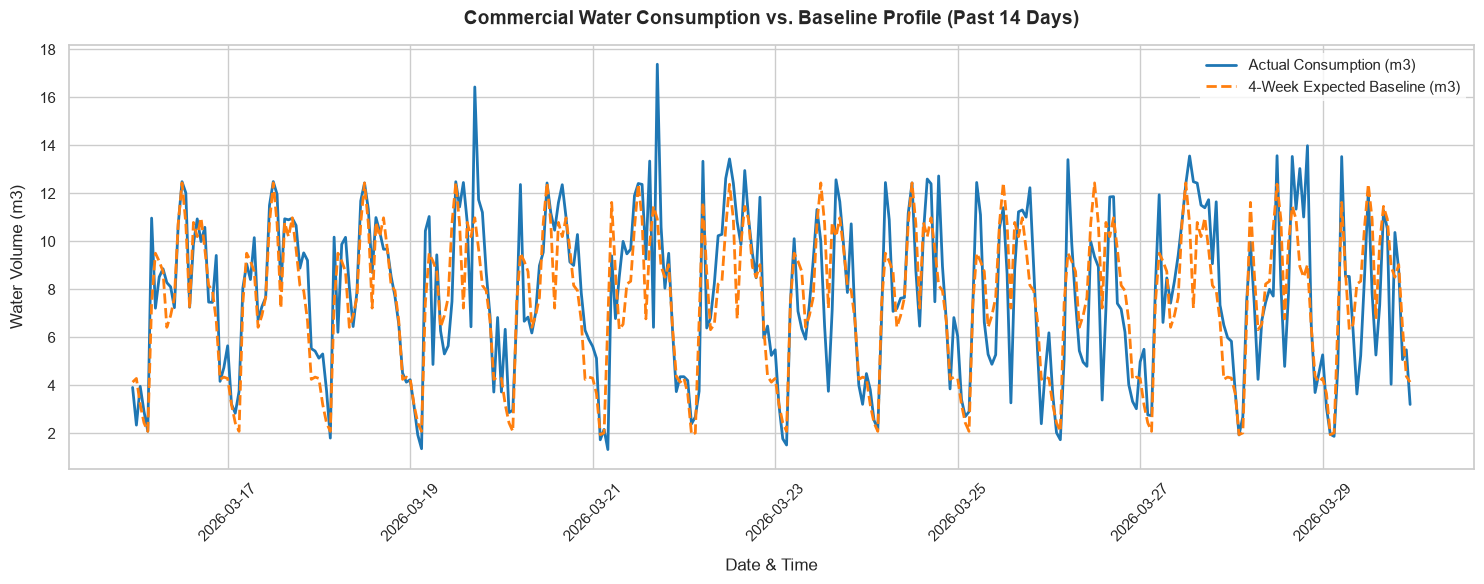

In [22]:
# 1. Filter for the last 14 days of the dataset using your 'Hourly' column
last_14_days = df[df['Hourly'] >= (df['Hourly'].max() - pd.Timedelta(days=14))]

# 2. Initialize the plot canvas
plt.figure(figsize=(15, 6))

# 3. Plot Actual Consumption (FIXED: x is now 'Hourly')
sns.lineplot(
    data=last_14_days, 
    x='Hourly', 
    y='Consumption m3', 
    label='Actual Consumption (m3)', 
    color='#1f77b4', 
    linewidth=2
)

# 4. Plot the 4-Week Expected Baseline (FIXED: x is now 'Hourly')
sns.lineplot(
    data=last_14_days, 
    x='Hourly', 
    y='recent_baseline_m3', 
    label='4-Week Expected Baseline (m3)', 
    color='#ff7f0e', 
    linestyle='--', 
    linewidth=2
)

# 5. Customize chart appearance and text
plt.title('Commercial Water Consumption vs. Baseline Profile (Past 14 Days)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date & Time', fontsize=12, labelpad=10)
plt.ylabel('Water Volume (m3)', fontsize=12, labelpad=10)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# 6. Rotate date labels for easy reading
plt.xticks(rotation=45)
plt.tight_layout()

# 7. Render plot
plt.show()


In [26]:
# --- Table 1: Check for Old Pre-Existing Leaks (Night Flow Analysis) ---
# Filter data for deep night hours (1 AM to 4 AM) across the entire 5 months
night_data = df[df['hour'].isin([1, 2, 3, 4])].copy()

# Group by month to see if the minimum usage has crawled upward over time
night_data['month'] = night_data['Hourly'].dt.to_period('M')
night_summary = night_data.groupby('month').agg(
    absolute_minimum_m3=('Consumption m3', 'min'),
    typical_night_median_m3=('Consumption m3', 'median'),
    typical_night_maximum_m3=('Consumption m3', 'max')
).reset_index()

print("### TABLE 1: LONG-TERM NIGHT FLOW HISTORY (1:00 AM - 4:00 AM)")
print("Look closely here: If the absolute minimum or median goes up month-by-month and never hits zero, a leak started early.")
print(night_summary.to_string(index=False))


# --- Table 2: Check for New Burst Leaks (Highest Deviations in Recent Period) ---
# Filter for just the recent 4 weeks where we have active baseline comparison
recent_df = df[df['period'] == 'Recent'].copy()

# Find the top 10 hours with the highest absolute deviation from your baseline
top_deviations = recent_df.sort_values(by='abs_deviation_m3', ascending=False).head(10)

# Format columns for easy reading
top_deviations_summary = pd.DataFrame({
    'Timestamp': top_deviations['Hourly'].dt.strftime('%Y-%m-%d %H:%M'),
    'Actual Consumption': top_deviations['Consumption m3'].round(4),
    'Expected Baseline': top_deviations['recent_baseline_m3'].round(4),
    'Extra Water Wasted (Abs Dev)': top_deviations['abs_deviation_m3'].round(4),
    'Z-Score (Severity)': top_deviations['z_score_deviation'].round(1)
})

print("\n\n### TABLE 2: TOP 10 HIGHEST DEVIATION EVENTS (RECENT WEEKS)")
print("Look closely here: If the Z-score is above 3.0, it is highly anomalous. If it is massive (e.g., 5.0+), it is a major burst.")
print(top_deviations_summary.to_string(index=False))


### TABLE 1: LONG-TERM NIGHT FLOW HISTORY (1:00 AM - 4:00 AM)
Look closely here: If the absolute minimum or median goes up month-by-month and never hits zero, a leak started early.
  month  absolute_minimum_m3  typical_night_median_m3  typical_night_maximum_m3
2025-10                0.914                   3.4165                     7.813
2025-11                1.002                   3.9785                     7.717
2025-12                0.640                   2.2815                     7.382
2026-01                0.653                   1.9215                     7.459
2026-02                0.548                   2.1380                     7.289
2026-03                0.947                   3.0600                    10.970


### TABLE 2: TOP 10 HIGHEST DEVIATION EVENTS (RECENT WEEKS)
Look closely here: If the Z-score is above 3.0, it is highly anomalous. If it is massive (e.g., 5.0+), it is a major burst.
       Timestamp  Actual Consumption  Expected Baseline  Extra Water Wast